# Testing ROSE segmentation on U-Net Pretrained on OCTA-500

In [3]:
import sys; sys.path.append('/users/egottfri/code/octa-segmentation/src')
import os, glob, numpy as np, torch, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from model import build_model, remap_legacy_state_dict
from dataset import OCTADataset
import evaluate

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
ROSE    = '/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1/SVC'
RESULTS = '/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary'

ckpts = sorted(glob.glob(f'{RESULTS}/*.pth'))
print('checkpoints:', *ckpts, sep='\n  ')

def load_model(ckpt):
    m = build_model('unet', in_channels=1, num_classes=1).to(device)
    sd = torch.load(ckpt, map_location=device)
    if isinstance(sd, dict) and 'state_dict' in sd:      # current run_kfold format
        sd = sd['state_dict']
    elif isinstance(sd, dict) and 'model_state_dict' in sd:
        sd = sd['model_state_dict']
    m.load_state_dict(remap_legacy_state_dict(sd))       # pre-ConvBlock-refactor checkpoint
    m.eval(); return m

models = [load_model(c) for c in ckpts]
print(f'loaded {len(models)} fold model(s) on {device}')

checkpoints:
  /users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold1.pth
  /users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold2.pth
  /users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold3.pth
  /users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold4.pth
  /users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold5.pth
loaded 5 fold model(s) on cpu


In [4]:
def pairs(split):
    out = []
    for ip in sorted(glob.glob(f'{ROSE}/{split}/img/*.tif')):
        gp = f'{ROSE}/{split}/gt/' + os.path.basename(ip)
        if os.path.exists(gp): out.append((ip, gp))
    return out

data = pairs('train') + pairs('test')
img_paths, gt_paths = [a for a, _ in data], [b for _, b in data]
print(len(data), 'ROSE-1 SVC pairs')

ds     = OCTADataset(img_paths, gt_paths, augment=False)   # <-- confirm no-aug kwarg vs dataset.py
loader = DataLoader(ds, batch_size=1, shuffle=False)

@torch.no_grad()
def ensemble_prob(x):
    x = x.to(device); acc = 0.
    for m in models: acc = acc + torch.sigmoid(m(x))
    return (acc / len(models))[0, 0].cpu().numpy()

results, show = [], []
for i, (img, mask) in enumerate(loader):
    prob = ensemble_prob(img)
    gt, pred = (mask[0,0].numpy() > 0.5).astype(np.uint8), (prob > 0.5).astype(np.uint8)
    r = evaluate.evaluate(pred, gt, prob_map=prob)
    r['pred_density'], r['gt_density'] = pred.mean(), gt.mean()
    results.append(r)
    if i < 6: show.append((img[0,0].numpy(), gt, prob, pred))
print('inference done')

39 ROSE-1 SVC pairs
inference done


In [5]:
skip = {'pred_density', 'gt_density'}
print(f'ROSE-1 SVC zero-shot | frozen OCTA-500 model | N={len(results)}\n')
for k in [k for k in results[0] if k not in skip]:
    v = np.array([r[k] for r in results])
    print(f'  {k:12s} {v.mean():.4f} ± {v.std():.4f}')
print(f'\n  pred density {np.mean([r["pred_density"] for r in results]):.1%}'
      f'   vs   GT density {np.mean([r["gt_density"] for r in results]):.1%}')

ROSE-1 SVC zero-shot | frozen OCTA-500 model | N=39

  dice         0.5578 ± 0.0348
  iou          0.3876 ± 0.0331
  sensitivity  0.7477 ± 0.0384
  specificity  0.7757 ± 0.0451
  precision    0.4485 ± 0.0509
  auprc        0.6411 ± 0.0305

  pred density 32.5%   vs   GT density 19.3%


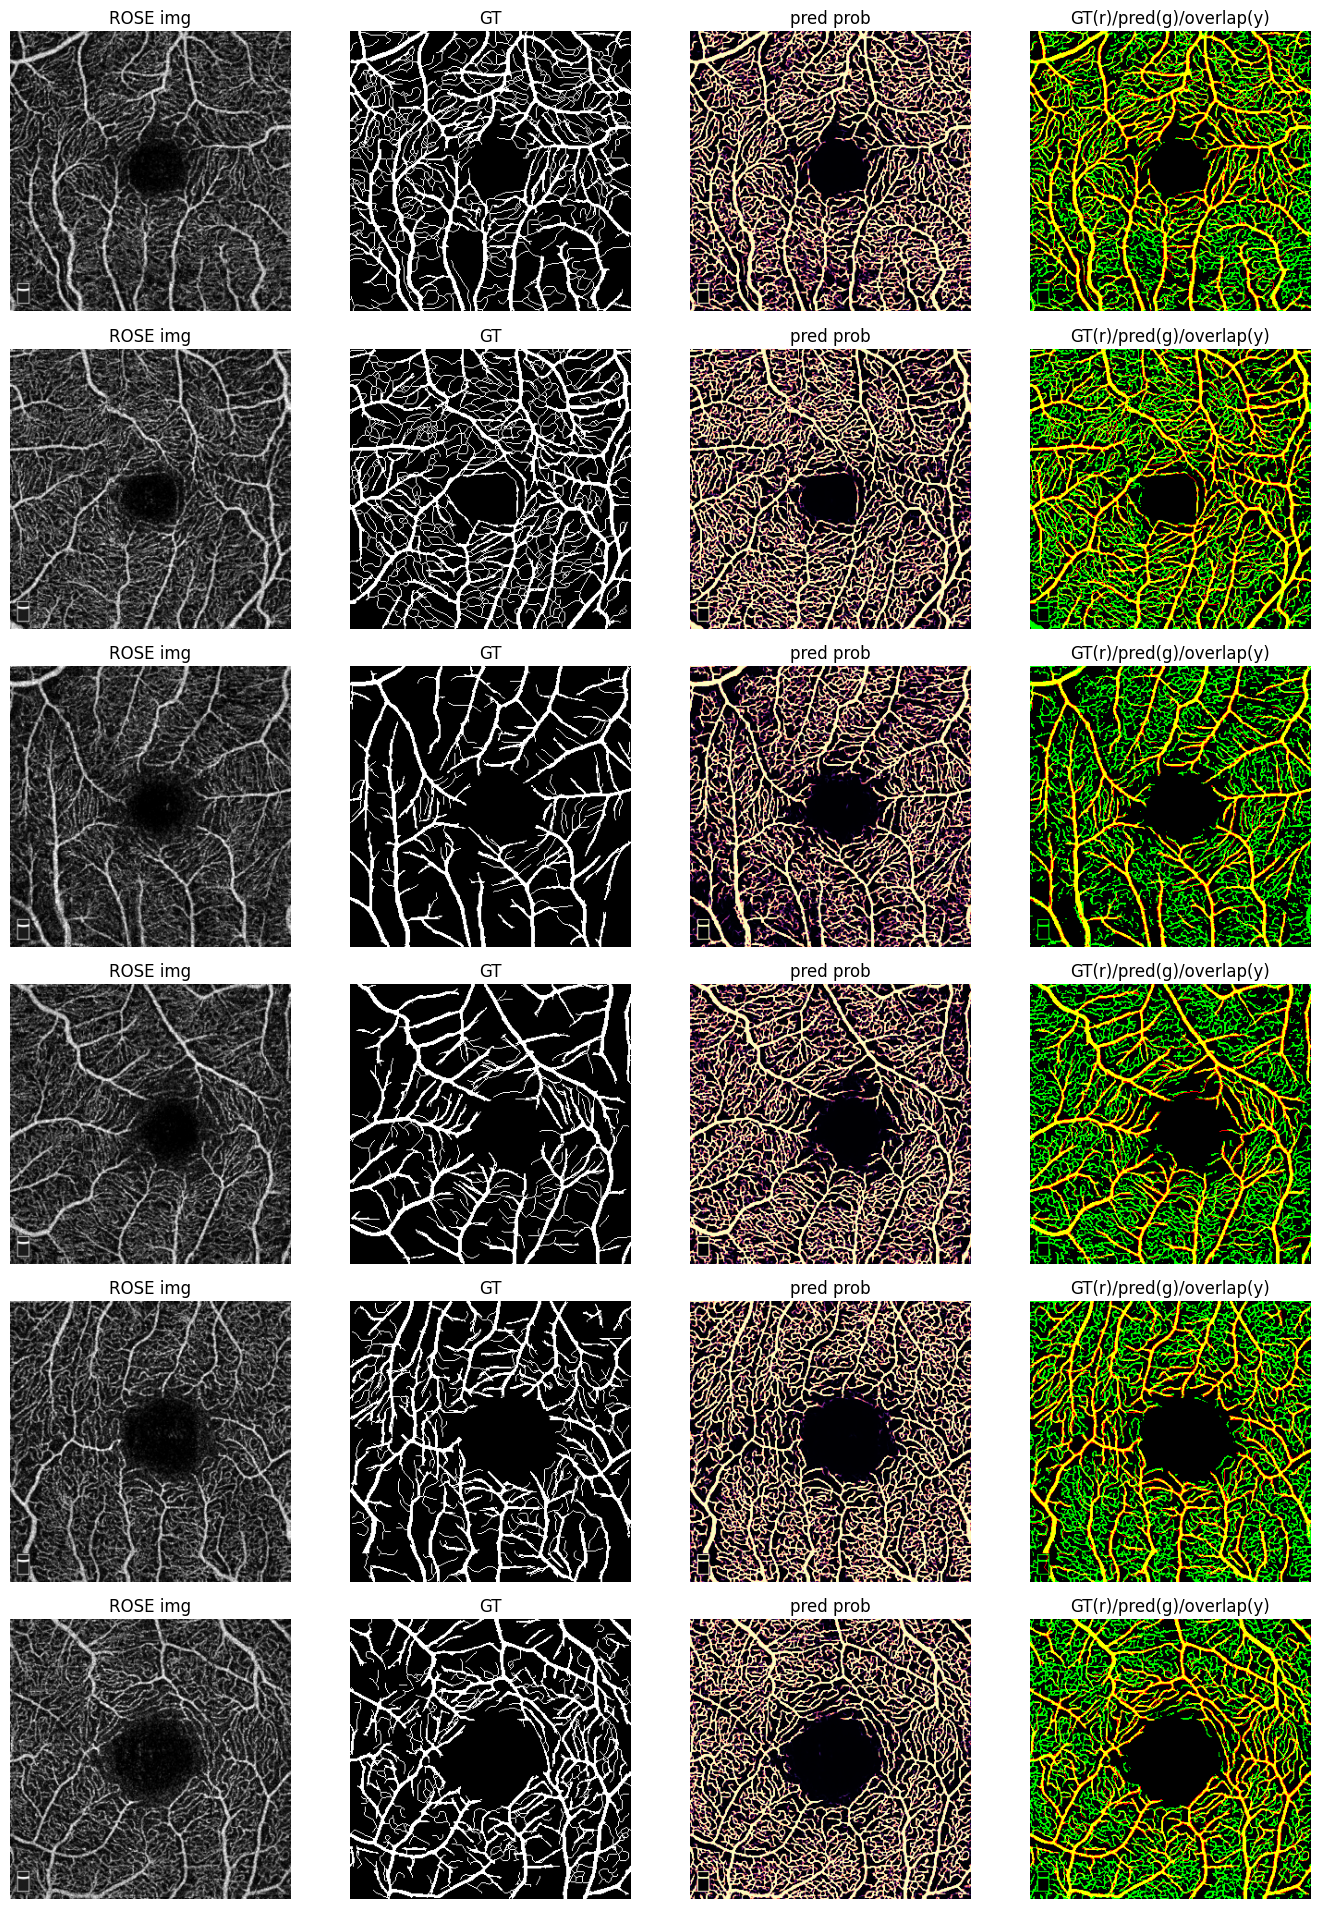

In [6]:
fig, axes = plt.subplots(len(show), 4, figsize=(14, 3.2*len(show)))
for row, (img, gt, prob, pred) in zip(np.atleast_2d(axes), show):
    row[0].imshow(img, cmap='gray');   row[0].set_title('ROSE img')
    row[1].imshow(gt,  cmap='gray');   row[1].set_title('GT')
    row[2].imshow(prob, cmap='magma'); row[2].set_title('pred prob')
    ov = np.zeros((*gt.shape, 3)); ov[...,0] = gt; ov[...,1] = pred
    row[3].imshow(ov);                 row[3].set_title('GT(r)/pred(g)/overlap(y)')
    for a in row: a.axis('off')
plt.tight_layout(); plt.show()

In [7]:
import cv2
for variant in ['gt', 'thin_gt', 'thick_gt', 'thick_gt_converted']:
    fs = sorted(glob.glob(f'{ROSE}/train/{variant}/*.tif')) + \
         sorted(glob.glob(f'{ROSE}/train/{variant}/*.png'))
    if not fs:
        print(f'{variant:20s} — not found'); continue
    d = np.mean([(cv2.imread(f, 0) > 127).mean() for f in fs])
    print(f'{variant:20s} {len(fs):3d} files   density {d:.1%}')

gt                    30 files   density 19.6%
thin_gt               30 files   density 8.2%
thick_gt              30 files   density 15.4%
thick_gt_converted    30 files   density 15.4%


In [8]:
import inspect
print(inspect.getsource(OCTADataset.__init__))

    def __init__(self, img_paths, mask_paths, augment=False):
        # store image and mask paths
        # store augmentation flag
        # define augmentation transforms

        self.img_path = img_paths
        self.mask_path = mask_paths
        self.augment = augment


        # validation transform, just normalize
        self.val_transform = A.Compose([
            A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0), 
            ToTensorV2()
        ])

        # training transform, random augmentations
        self.train_transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
            ToTensorV2()
        ])



In [9]:
ds_check = OCTADataset(img_paths, gt_paths, augment=False)
a = ds_check[0][0]
b = ds_check[0][0]
print('identical across reloads:', torch.equal(a, b))   # must be True if no random aug

identical across reloads: True


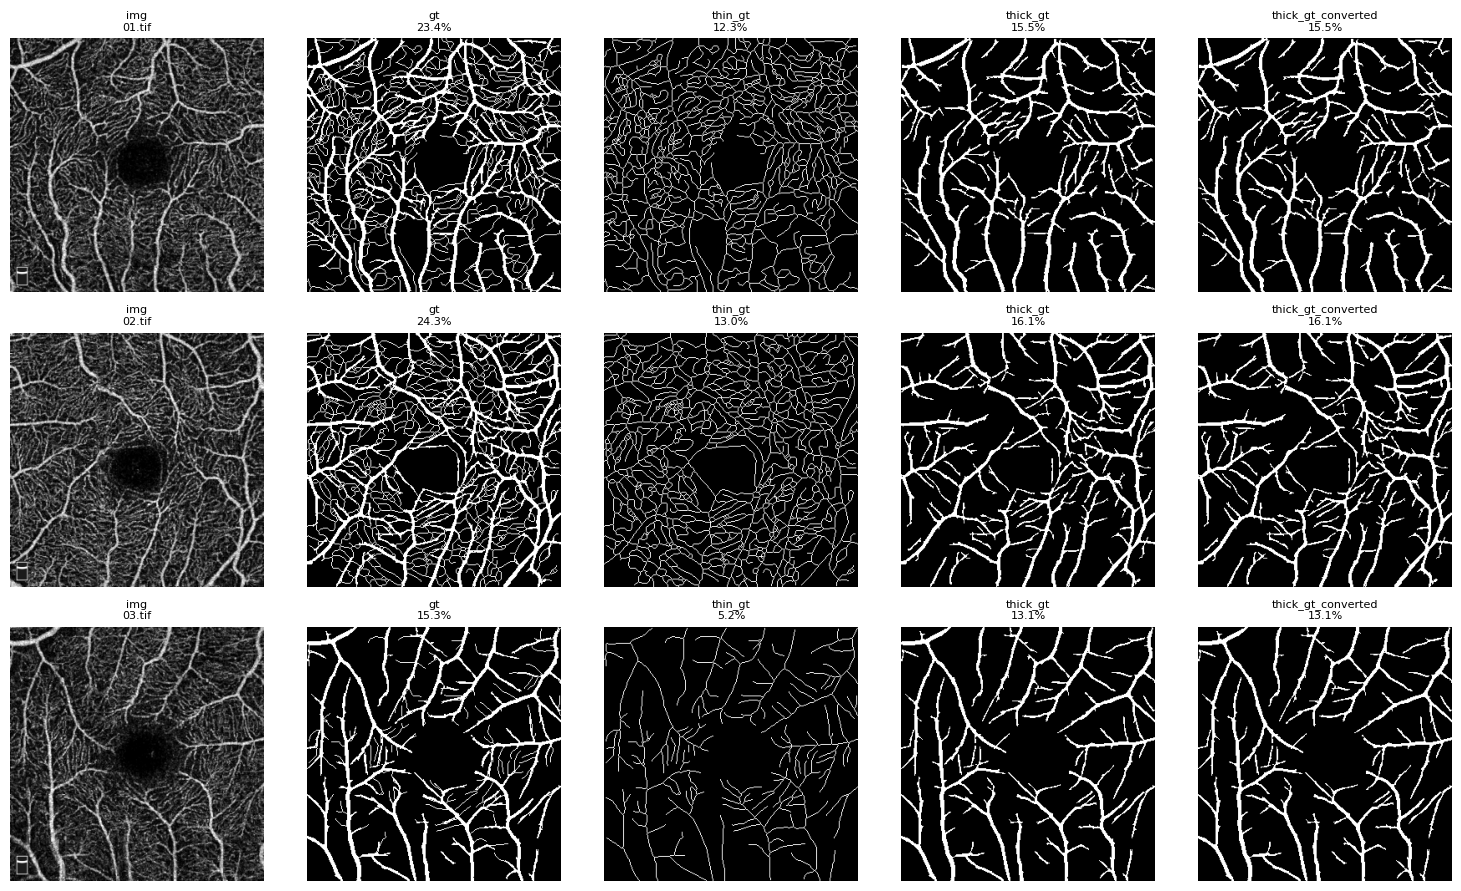

In [10]:
import cv2
variants = ['gt', 'thin_gt', 'thick_gt', 'thick_gt_converted']
imgs = sorted(glob.glob(f'{ROSE}/train/img/*.tif'))[:3]   # first 3 subjects

fig, axes = plt.subplots(len(imgs), 1 + len(variants), figsize=(3*(1+len(variants)), 3*len(imgs)))
for row, ip in zip(np.atleast_2d(axes), imgs):
    name = os.path.basename(ip)
    row[0].imshow(cv2.imread(ip, 0), cmap='gray'); row[0].set_title(f'img\n{name}', fontsize=8)
    for a, v in zip(row[1:], variants):
        gp = f'{ROSE}/train/{v}/{name}'
        if os.path.exists(gp):
            g = cv2.imread(gp, 0)
            a.imshow(g, cmap='gray'); a.set_title(f'{v}\n{(g>127).mean():.1%}', fontsize=8)
        else:
            a.text(0.5, 0.5, 'missing', ha='center'); a.set_title(v, fontsize=8)
    for a in row: a.axis('off')
plt.tight_layout(); plt.show()

In [11]:
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    ds_, dens = [], []
    for _, gt, prob, _ in show:
        p = (prob > t).astype(np.uint8)
        ds_.append(evaluate.dice(p, gt)); dens.append(p.mean())
    print(f'  t={t:.2f}  dice {np.mean(ds_):.3f}  pred_density {np.mean(dens):.1%}')

  t=0.50  dice 0.549  pred_density 34.1%
  t=0.60  dice 0.554  pred_density 32.5%
  t=0.70  dice 0.560  pred_density 30.8%
  t=0.80  dice 0.567  pred_density 28.6%
  t=0.90  dice 0.576  pred_density 25.1%


In [14]:
import sys
!{sys.executable} -m pip install scikit-image
import skimage
from skimage.morphology import skeletonize

def cldice_parts(pred, gt, eps=1e-7):
    pred, gt = pred.astype(bool), gt.astype(bool)
    sp, sg = skeletonize(pred), skeletonize(gt)
    tprec = (sp & gt).sum()   / (sp.sum() + eps)   # pred centerlines inside GT
    tsens = (sg & pred).sum() / (sg.sum() + eps)   # GT centerlines inside pred
    return 2*tprec*tsens/(tprec+tsens+eps), tprec, tsens

cld, tp, ts, dice = [], [], [], []
for img, mask in loader:
    prob = ensemble_prob(img)
    gt   = (mask[0,0].numpy() > 0.5).astype(np.uint8)
    pred = (prob > 0.5).astype(np.uint8)
    c, p, s = cldice_parts(pred, gt)
    cld.append(c); tp.append(p); ts.append(s); dice.append(evaluate.dice(pred, gt))

import numpy as np
print(f'ROSE-1 SVC zero-shot | frozen OCTA-500 | N={len(cld)} | thresh 0.5\n')
print(f'  pixel Dice                     {np.mean(dice):.4f} ± {np.std(dice):.4f}')
print(f'  clDice (topology)              {np.mean(cld):.4f} ± {np.std(cld):.4f}')
print(f'  Tsens  GT tree covered by pred {np.mean(ts):.4f} ± {np.std(ts):.4f}')
print(f'  Tprec  pred lines inside GT    {np.mean(tp):.4f} ± {np.std(tp):.4f}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 79.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
ROSE-1 SVC zero-shot | frozen OCTA-500 | N=39 | thresh 0.5

  pixel Dice                     0.5578 ± 0.0348
  clDice (topology)              0.5221 ± 0.0433
  Tsens  GT tree covered by pred 0.7741 ± 0.0554
  Tprec  pred lines inside GT    0.3974 ± 0.0507


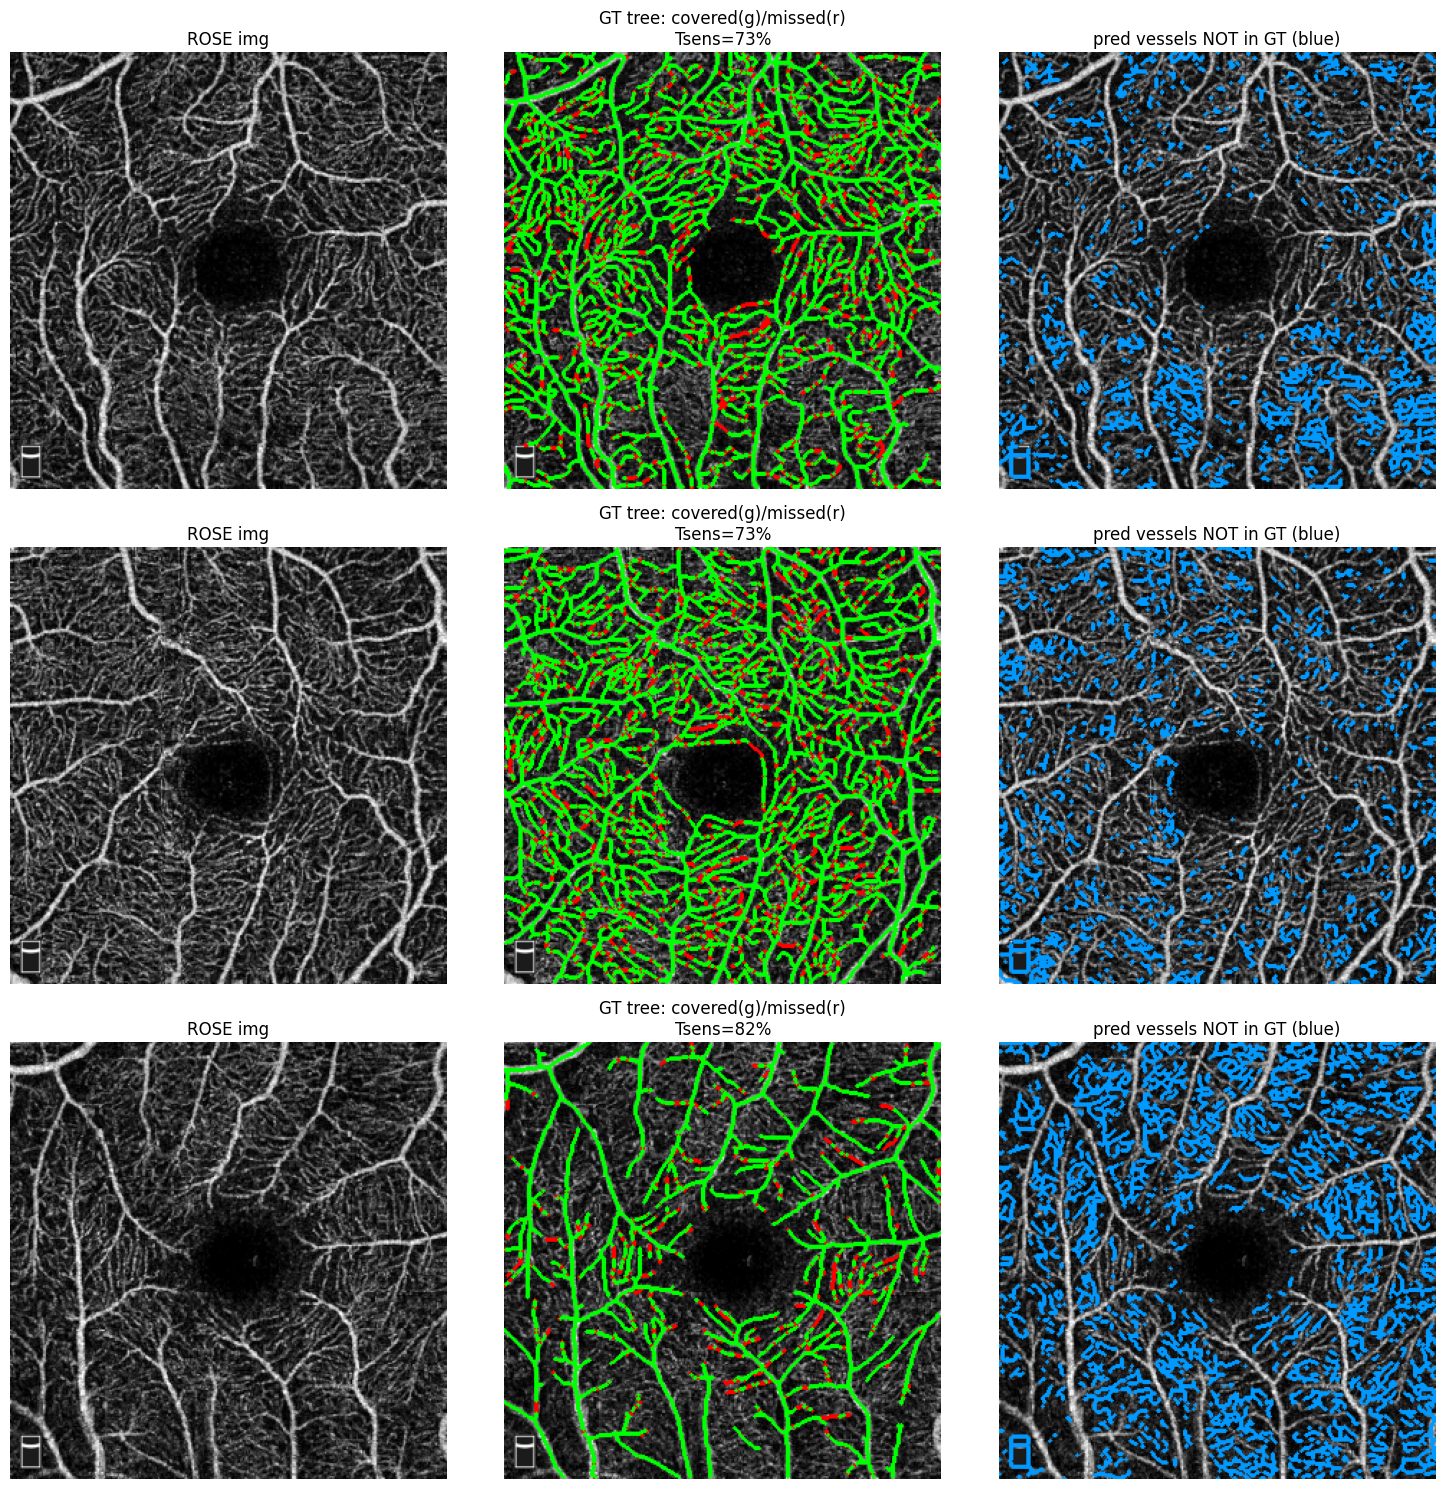

In [17]:
from skimage.morphology import skeletonize, dilation, disk

def norm(a):                                  # grayscale -> 0..1 RGB base
    a = a.astype(float)
    return np.stack([(a - a.min())/(np.ptp(a) + 1e-9)]*3, -1)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for row, (img, gt, prob, pred) in zip(axes, show[:3]):
    pred_mask = prob > 0.5
    gt_skel   = skeletonize(gt.astype(bool))
    covered   = gt_skel & pred_mask
    missed    = gt_skel & ~pred_mask
    fat = lambda s: dilation(s, disk(1))

    row[0].imshow(img, cmap='gray'); row[0].set_title('ROSE img'); row[0].axis('off')

    base = norm(img)
    base[fat(missed)]  = [1, 0, 0]            # red   = missed GT vessels
    base[fat(covered)] = [0, 1, 0]            # green = covered GT vessels
    row[1].imshow(base)
    row[1].set_title(f'GT tree: covered(g)/missed(r)\nTsens={covered.sum()/gt_skel.sum():.0%}')
    row[1].axis('off')

    extra = skeletonize(pred_mask) & ~dilation(gt.astype(bool), disk(2))
    comp = norm(img)
    comp[fat(extra)] = [0, 0.6, 1]            # blue = pred vessels outside GT
    row[2].imshow(comp); row[2].set_title('pred vessels NOT in GT (blue)'); row[2].axis('off')
plt.tight_layout(); plt.show()

# Takeaways
The U-Net model trained on OCTA-500, which achieved a Dice score of 0.8976 on an unseen test set of 40 OCTA-500 images, achieved a Dice of 0.5578 on a test set of 39 ROSE-1 images.